# 03. GNN Training — 10 Graphs × 5 Models 전체 비교

**Input** : `graphs/graph_*.pt` (10가지 엣지 조합)  
**목표** : 엣지 조합 × GNN 모델 전체 Grid Search — Test Macro F1 / PR-AUC 비교

---

## 엣지 종류 및 설계 근거

### R-U-R (Review-User-Review)
- **연결 기준**: 같은 유저(`user_int`)가 작성한 리뷰끼리 연결
- **근거**: 사기 리뷰어는 여러 식당에 반복적으로 리뷰를 남기는 패턴을 보임. 동일 유저의 리뷰 네트워크를 통해 조직적 행동 패턴을 포착
- **특징**: 엣지 수가 가장 적어 sparse → 노이즈 적고 신호가 명확

### R-T-R (Review-Time-Review)
- **연결 기준**: 같은 식당(`prod_int`)에 같은 연월(`year_month`)에 작성된 리뷰끼리 연결
- **근거**: 사기 리뷰는 특정 캠페인 기간에 집중적으로 발생(burst 패턴). 시간적 군집성으로 조직적 캠페인 탐지
- **특징**: 엣지 수가 가장 많음 → 정보 풍부, 노이즈도 많음

### R-X-R (Review-eXtreme-Review)
- **연결 기준**: 같은 식당에 극단 별점(1점 또는 5점)을 남긴 리뷰끼리 연결
- **근거**: 사기 리뷰의 핵심 특징인 극단적 평가(집중 공격 1점 / 집중 홍보 5점) 패턴 포착. 전체 리뷰의 43.5%가 극단 별점
- **특징**: 별점 조작 그룹을 직접 연결 — R-X-R만으로도 사기 클러스터 식별 가능

### R-S-R (Review-Star-Review)
- **연결 기준**: 같은 식당에 같은 별점(1~5점)을 남긴 리뷰끼리 연결
- **근거**: R-X-R보다 넓은 범위의 평점 동조 패턴 탐지. 동일 별점 그룹 내 리뷰 유사성으로 이상 패턴 포착
- **특징**: R-X-R의 superset — 더 많은 연결, 더 넓은 맥락 제공

---

## 실험 조합 (10가지)

| 조합 | 포함 관계 수 | 특징 |
|---|---|---|
| RUR | 1 | 유저 행동 패턴 단독 |
| RTR | 1 | 시간적 군집성 단독 |
| RXR | 1 | 극단 별점 단독 |
| RSR | 1 | 동일 평점 동조 단독 |
| RUR_RTR | 2 | 유저 + 시간 |
| RUR_RXR | 2 | 유저 + 극단별점 |
| RTR_RXR | 2 | 시간 + 극단별점 |
| RUR_RTR_RXR | 3 | 유저 + 시간 + 극단별점 |
| RUR_RSR | 2 | 유저 + 동일평점 |
| RUR_RTR_RSR | 3 | 유저 + 시간 + 동일평점 |

---

## 비교 모델 (5가지)

| 모델 | 설명 |
|---|---|
| GCN | Graph Convolutional Network — 이웃 정보 정규화 후 단순 집계 |
| GraphSAGE | Sample & Aggregate — 이웃 샘플링 후 Mean Aggregation |
| GAT | Graph Attention Network — Attention으로 이웃에 가중치 부여 (1 Head) |
| MultiHeadGAT | Multi-Head GAT — 4개 Attention Head 병렬 사용, 다양한 관계 포착 |
| **RGCN** | **Relational GCN — 엣지 종류별 독립 가중치 행렬 학습 (다중 관계 특화)** |

> RGCN은 복합 엣지 조합(RUR_RTR 등)에서 각 관계 유형을 독립적으로 처리하므로, 단일 엣지 조합보다 복합 조합에서 강점을 보일 수 있음

---

## 성능 지표
- **Test Macro F1**: 클래스 불균형 상황에서의 전반적 분류 성능 (정상/사기 클래스 평균)
- **Test PR-AUC**: Precision-Recall 곡선 아래 면적 — 사기 탐지의 핵심 지표

In [8]:
# ── Imports ────────────────────────────────────────────
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from torch_geometric.nn import SAGEConv, GCNConv, GATConv, RGCNConv
from sklearn.metrics import average_precision_score, f1_score

# ── 경로 설정 ──────────────────────────────────────────
BASE_DIR  = os.path.abspath(".")
GRAPH_DIR = os.path.join(BASE_DIR, "graphs")
MODEL_DIR = os.path.join(BASE_DIR, "models")
os.makedirs(MODEL_DIR, exist_ok=True)

# ── 하이퍼파라미터 ────────────────────────────────────
HIDDEN_DIM  = 128   # 256 → OOM 방지를 위해 축소
NUM_LAYERS  = 2    # 3   → OOM 방지를 위해 축소
DROPOUT     = 0.4
LR          = 0.001
EPOCHS      = 500
PATIENCE    = 40
GAT_HEADS   = 4
MH_HIDDEN   = 64

# ── 실험 대상 그래프 (10종) ───────────────────────────
GRAPH_NAMES = [
    "RUR", "RTR", "RXR", "RSR",
    "RUR_RTR", "RUR_RXR", "RTR_RXR", "RUR_RTR_RXR",
    "RUR_RSR", "RUR_RTR_RSR",
]

# ── GPU 설정 ──────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device  : {device}")
if device.type == "cuda":
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
    print(f"VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"실험 조합 : {len(GRAPH_NAMES)}종 그래프 × 5종 모델 = {len(GRAPH_NAMES) * 5}번 학습")

Device  : cuda
GPU     : NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM    : 12.8 GB
실험 조합 : 10종 그래프 × 5종 모델 = 50번 학습


In [9]:
# ── Step 1. 모델 정의 (5종) ────────────────────────────

class FraudGCN(torch.nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=3, dropout=0.4, **kwargs):
        super().__init__()
        self.convs   = torch.nn.ModuleList()
        self.bns     = torch.nn.ModuleList()
        self.dropout = dropout
        self.convs.append(GCNConv(in_ch, hidden_ch))
        self.bns.append(torch.nn.BatchNorm1d(hidden_ch))
        for _ in range(num_layers - 1):
            self.convs.append(GCNConv(hidden_ch, hidden_ch))
            self.bns.append(torch.nn.BatchNorm1d(hidden_ch))
        self.classifier = torch.nn.Linear(hidden_ch, out_ch)

    def forward(self, x, edge_index, edge_type=None):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)


class FraudGraphSAGE(torch.nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=3, dropout=0.4, **kwargs):
        super().__init__()
        self.convs   = torch.nn.ModuleList()
        self.bns     = torch.nn.ModuleList()
        self.dropout = dropout
        self.convs.append(SAGEConv(in_ch, hidden_ch))
        self.bns.append(torch.nn.BatchNorm1d(hidden_ch))
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_ch, hidden_ch))
            self.bns.append(torch.nn.BatchNorm1d(hidden_ch))
        self.classifier = torch.nn.Linear(hidden_ch, out_ch)

    def forward(self, x, edge_index, edge_type=None):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)


class FraudGAT(torch.nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, num_layers=3, dropout=0.4, **kwargs):
        super().__init__()
        self.convs   = torch.nn.ModuleList()
        self.bns     = torch.nn.ModuleList()
        self.dropout = dropout
        self.convs.append(GATConv(in_ch, hidden_ch, heads=1, dropout=dropout))
        self.bns.append(torch.nn.BatchNorm1d(hidden_ch))
        for _ in range(num_layers - 1):
            self.convs.append(GATConv(hidden_ch, hidden_ch, heads=1, dropout=dropout))
            self.bns.append(torch.nn.BatchNorm1d(hidden_ch))
        self.classifier = torch.nn.Linear(hidden_ch, out_ch)

    def forward(self, x, edge_index, edge_type=None):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)


class FraudMultiHeadGAT(torch.nn.Module):
    def __init__(self, in_ch, hidden_ch, out_ch, heads=4, num_layers=3, dropout=0.4, **kwargs):
        super().__init__()
        self.convs   = torch.nn.ModuleList()
        self.bns     = torch.nn.ModuleList()
        self.dropout = dropout
        self.convs.append(GATConv(in_ch, hidden_ch, heads=heads, dropout=dropout, concat=True))
        self.bns.append(torch.nn.BatchNorm1d(hidden_ch * heads))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_ch * heads, hidden_ch, heads=heads, dropout=dropout, concat=True))
            self.bns.append(torch.nn.BatchNorm1d(hidden_ch * heads))
        self.convs.append(GATConv(hidden_ch * heads, hidden_ch, heads=1, dropout=dropout, concat=False))
        self.bns.append(torch.nn.BatchNorm1d(hidden_ch))
        self.classifier = torch.nn.Linear(hidden_ch, out_ch)

    def forward(self, x, edge_index, edge_type=None):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)


class FraudRGCN(torch.nn.Module):
    """Relational GCN: 엣지 종류별 독립 가중치 행렬로 다중 관계 그래프 처리"""
    def __init__(self, in_ch, hidden_ch, out_ch, num_relations=1, num_layers=3, dropout=0.4, **kwargs):
        super().__init__()
        self.convs   = torch.nn.ModuleList()
        self.bns     = torch.nn.ModuleList()
        self.dropout = dropout
        self.convs.append(RGCNConv(in_ch, hidden_ch, num_relations))
        self.bns.append(torch.nn.BatchNorm1d(hidden_ch))
        for _ in range(num_layers - 1):
            self.convs.append(RGCNConv(hidden_ch, hidden_ch, num_relations))
            self.bns.append(torch.nn.BatchNorm1d(hidden_ch))
        self.classifier = torch.nn.Linear(hidden_ch, out_ch)

    def forward(self, x, edge_index, edge_type=None):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index, edge_type)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)


MODEL_NAMES = ["GCN", "GraphSAGE", "GAT", "MultiHeadGAT", "RGCN"]

def build_model(model_name, in_ch, num_relations):
    if model_name == "GCN":
        return FraudGCN(in_ch, HIDDEN_DIM, 2, NUM_LAYERS, DROPOUT).to(device)
    elif model_name == "GraphSAGE":
        return FraudGraphSAGE(in_ch, HIDDEN_DIM, 2, NUM_LAYERS, DROPOUT).to(device)
    elif model_name == "GAT":
        return FraudGAT(in_ch, HIDDEN_DIM, 2, NUM_LAYERS, DROPOUT).to(device)
    elif model_name == "MultiHeadGAT":
        return FraudMultiHeadGAT(in_ch, MH_HIDDEN, 2, GAT_HEADS, NUM_LAYERS, DROPOUT).to(device)
    elif model_name == "RGCN":
        return FraudRGCN(in_ch, HIDDEN_DIM, 2, num_relations, NUM_LAYERS, DROPOUT).to(device)

print(f"모델 5종 정의 완료: {', '.join(MODEL_NAMES)}")

모델 5종 정의 완료: GCN, GraphSAGE, GAT, MultiHeadGAT, RGCN


In [10]:
# ── Step 2. 데이터 로드 ────────────────────────────────
# ── Step 2. 학습 & 평가 함수 (edge_type 지원) ─────────

def train_epoch(model, data, optimizer, criterion):
    model.train()
    optimizer.zero_grad()
    edge_type = getattr(data, 'edge_type', None)
    out  = model(data.x, data.edge_index, edge_type)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()


@torch.no_grad()
def evaluate(model, data, mask):
    model.eval()
    edge_type = getattr(data, 'edge_type', None)
    out    = model(data.x, data.edge_index, edge_type)
    probs  = F.softmax(out, dim=1)[:, 1].cpu().numpy()
    preds  = out.argmax(dim=1).cpu().numpy()
    labels = data.y.cpu().numpy()
    m      = mask.cpu().numpy()
    return (
        average_precision_score(labels[m], probs[m]),
        f1_score(labels[m], preds[m], average="macro", zero_division=0),
    )


def run_experiment(exp_name, model, data, class_weight):
    torch.manual_seed(42)
    save_path = os.path.join(MODEL_DIR, f"best_{exp_name}.pt")

    criterion = torch.nn.CrossEntropyLoss(weight=class_weight)
    optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=5e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=10
    )

    best_val, best_epoch, no_improve = 0, 0, 0

    for epoch in range(1, EPOCHS + 1):
        loss = train_epoch(model, data, optimizer, criterion)
        val_prauc, val_f1 = evaluate(model, data, data.val_mask)
        scheduler.step(val_prauc)

        if val_prauc > best_val:
            best_val, best_epoch, no_improve = val_prauc, epoch, 0
            torch.save(model.state_dict(), save_path)
        else:
            no_improve += 1

        if no_improve >= PATIENCE:
            break

    model.load_state_dict(torch.load(save_path, map_location=device, weights_only=True))
    test_prauc, test_f1 = evaluate(model, data, data.test_mask)

    return {
        "Best Epoch"   : best_epoch,
        "Val PR-AUC"   : round(best_val, 4),
        "Test PR-AUC"  : round(test_prauc, 4),
        "Test Macro F1": round(test_f1, 4),
    }

print("학습 함수 정의 완료 (edge_type 지원)")

학습 함수 정의 완료 (edge_type 지원)


In [11]:
# ── Step 3. 학습 & 평가 함수 ──────────────────────────

# ── Step 3. 전체 그리드 실험 (10 그래프 × 5 모델) ────
# 재실행 시 완료된 실험은 자동 SKIP, OOM은 NaN으로 기록

RESULTS_PATH = os.path.join(BASE_DIR, "grid_results.csv")

# 기존 결과 로드 (재실행 시 이어받기)
if os.path.exists(RESULTS_PATH):
    _prev = pd.read_csv(RESULTS_PATH)
    all_results = _prev.to_dict("records")
    done_set    = {(r["Graph"], r["Model"]) for r in all_results}
    print(f"기존 결과 {len(all_results)}개 로드 — 완료된 실험은 SKIP")
else:
    all_results = []
    done_set    = set()

available = [g for g in GRAPH_NAMES
             if os.path.exists(os.path.join(GRAPH_DIR, f"graph_{g}.pt"))]
total     = len(available) * len(MODEL_NAMES)
done      = len(all_results)

print(f"사용 가능 그래프: {len(available)}/{len(GRAPH_NAMES)}종")
print(f"총 실험 수      : {total}번  (남은 실험: {total - done}번)\n")

import gc

# CUDA 계열 에러 여부 판별 함수
def _is_cuda_error(e: Exception) -> bool:
    msg = str(e).lower()
    cuda_keywords = ("out of memory", "cuda error", "device-side assert",
                     "cudaerror", "acceleratorerror")
    return any(kw in msg for kw in cuda_keywords)

def _cuda_reset():
    """CUDA 컨텍스트 복구 시도 — 실패해도 무시"""
    try:
        gc.collect()
        torch.cuda.empty_cache()
    except Exception:
        pass

for graph_name in available:
    data = torch.load(
        os.path.join(GRAPH_DIR, f"graph_{graph_name}.pt"),
        map_location=device, weights_only=False
    )
    num_rels = int(getattr(data, 'num_relations', 1))

    y_tr = data.y[data.train_mask].cpu().numpy()
    n_n, n_f = (y_tr == 0).sum(), (y_tr == 1).sum()
    cw = torch.tensor([1.0, n_n / n_f], dtype=torch.float).to(device)

    print(f"\n{'='*60}")
    print(f"  그래프: {graph_name:<15}  엣지: {data.num_edges:>10,}  관계 수: {num_rels}")
    print(f"{'='*60}")

    cuda_ctx_broken = False  # 이 그래프에서 CUDA 컨텍스트가 깨졌는지 추적

    for model_name in MODEL_NAMES:
        # 이미 완료된 실험 → 결과만 출력하고 SKIP
        if (graph_name, model_name) in done_set:
            prev = next(r for r in all_results
                        if r["Graph"] == graph_name and r["Model"] == model_name)
            f1_str    = f"{prev['Test Macro F1']:.4f}" if prev['Test Macro F1'] == prev['Test Macro F1'] else "NaN"
            prauc_str = f"{prev['Test PR-AUC']:.4f}"  if prev['Test PR-AUC']   == prev['Test PR-AUC']   else "NaN"
            print(f"  [DONE ] {model_name:<15} | F1: {f1_str} | PR-AUC: {prauc_str}")
            continue

        # 이전 실험에서 CUDA 컨텍스트가 깨진 경우 → 이 그래프의 나머지 모델 전부 SKIP
        if cuda_ctx_broken:
            row = {
                "Graph"        : graph_name,
                "Model"        : model_name,
                "Test PR-AUC"  : float("nan"),
                "Test Macro F1": float("nan"),
            }
            done += 1
            all_results.append(row)
            done_set.add((graph_name, model_name))
            pd.DataFrame(all_results).to_csv(RESULTS_PATH, index=False)
            print(f"  [{done:2d}/{total}] {model_name:<15} | [CUDA CTX BROKEN — SKIP]")
            continue

        # 미완료 실험 → 학습
        try:
            model = build_model(model_name, data.num_features, num_rels)
            res   = run_experiment(f"{graph_name}_{model_name}", model, data, cw)
            row   = {
                "Graph"        : graph_name,
                "Model"        : model_name,
                "Test PR-AUC"  : res["Test PR-AUC"],
                "Test Macro F1": res["Test Macro F1"],
            }
            done += 1
            print(f"  [{done:2d}/{total}] {model_name:<15} | "
                  f"F1: {res['Test Macro F1']:.4f} | PR-AUC: {res['Test PR-AUC']:.4f}")

        except Exception as e:
            if _is_cuda_error(e):
                try: del model
                except Exception: pass
                _cuda_reset()
                cuda_ctx_broken = True   # 이 그래프의 나머지 모델도 SKIP 플래그
                row = {
                    "Graph"        : graph_name,
                    "Model"        : model_name,
                    "Test PR-AUC"  : float("nan"),
                    "Test Macro F1": float("nan"),
                }
                done += 1
                err_tag = "OOM" if "out of memory" in str(e).lower() else "CUDA ERR"
                print(f"  [{done:2d}/{total}] {model_name:<15} | [{err_tag} — SKIP]")
            else:
                raise

        all_results.append(row)
        done_set.add((graph_name, model_name))
        pd.DataFrame(all_results).to_csv(RESULTS_PATH, index=False)

print("\n모든 실험 완료!")
print(f"결과 저장: {RESULTS_PATH}")




기존 결과 50개 로드 — 완료된 실험은 SKIP
사용 가능 그래프: 10/10종
총 실험 수      : 50번  (남은 실험: 0번)


  그래프: RUR              엣지:     89,504  관계 수: 1
  [DONE ] GCN             | F1: 0.6241 | PR-AUC: 0.4380
  [DONE ] GraphSAGE       | F1: 0.6280 | PR-AUC: 0.5075
  [DONE ] GAT             | F1: 0.5991 | PR-AUC: 0.2768
  [DONE ] MultiHeadGAT    | F1: 0.5861 | PR-AUC: 0.2743
  [DONE ] RGCN            | F1: 0.6155 | PR-AUC: 0.4928

  그래프: RTR              엣지:    733,708  관계 수: 1
  [DONE ] GCN             | F1: 0.5790 | PR-AUC: 0.2449
  [DONE ] GraphSAGE       | F1: 0.5555 | PR-AUC: 0.2952
  [DONE ] GAT             | F1: 0.5788 | PR-AUC: 0.2334
  [DONE ] MultiHeadGAT    | F1: 0.5618 | PR-AUC: 0.2381
  [DONE ] RGCN            | F1: 0.5853 | PR-AUC: 0.2942

  그래프: RXR              엣지:    542,348  관계 수: 1
  [DONE ] GCN             | F1: 0.5278 | PR-AUC: 0.2753
  [DONE ] GraphSAGE       | F1: 0.5846 | PR-AUC: 0.3046
  [DONE ] GAT             | F1: 0.5330 | PR-AUC: 0.2651
  [DONE ] MultiHeadGAT    | F1: 0.5446 | PR-AUC

In [12]:
# ── Step 4. 결과 요약 ────────────────────────────────

results_df = pd.DataFrame(all_results)

print("=" * 65)
print("  Top 10 — Test Macro F1 내림차순")
print("=" * 65)
print(results_df.sort_values("Test Macro F1", ascending=False)
      .head(10).to_string(index=False))
print("=" * 65)

best_f1    = results_df.loc[results_df["Test Macro F1"].idxmax()]
best_prauc = results_df.loc[results_df["Test PR-AUC"].idxmax()]
print(f"\n  ★ Best Macro F1  : {best_f1['Graph']} + {best_f1['Model']} "
      f"→ {best_f1['Test Macro F1']:.4f}")
print(f"  ★ Best PR-AUC    : {best_prauc['Graph']} + {best_prauc['Model']} "
      f"→ {best_prauc['Test PR-AUC']:.4f}")

print("\n  모델별 최적 그래프 (Macro F1 기준):")
for m in MODEL_NAMES:
    sub  = results_df[results_df["Model"] == m]
    best = sub.loc[sub["Test Macro F1"].idxmax()]
    print(f"    {m:<15} → {best['Graph']:<15} F1: {best['Test Macro F1']:.4f}")

  Top 10 — Test Macro F1 내림차순
      Graph     Model  Test PR-AUC  Test Macro F1
    RUR_RTR      RGCN       0.4955         0.6385
        RUR GraphSAGE       0.5075         0.6280
    RUR_RXR      RGCN       0.4967         0.6257
        RUR       GCN       0.4380         0.6241
        RUR      RGCN       0.4928         0.6155
    RUR_RXR GraphSAGE       0.4143         0.6097
    RUR_RTR GraphSAGE       0.3229         0.6003
        RUR       GAT       0.2768         0.5991
RUR_RTR_RXR GraphSAGE       0.3310         0.5988
        RSR GraphSAGE       0.3148         0.5906

  ★ Best Macro F1  : RUR_RTR + RGCN → 0.6385
  ★ Best PR-AUC    : RUR + GraphSAGE → 0.5075

  모델별 최적 그래프 (Macro F1 기준):
    GCN             → RUR             F1: 0.6241
    GraphSAGE       → RUR             F1: 0.6280
    GAT             → RUR             F1: 0.5991
    MultiHeadGAT    → RUR             F1: 0.5861
    RGCN            → RUR_RTR         F1: 0.6385


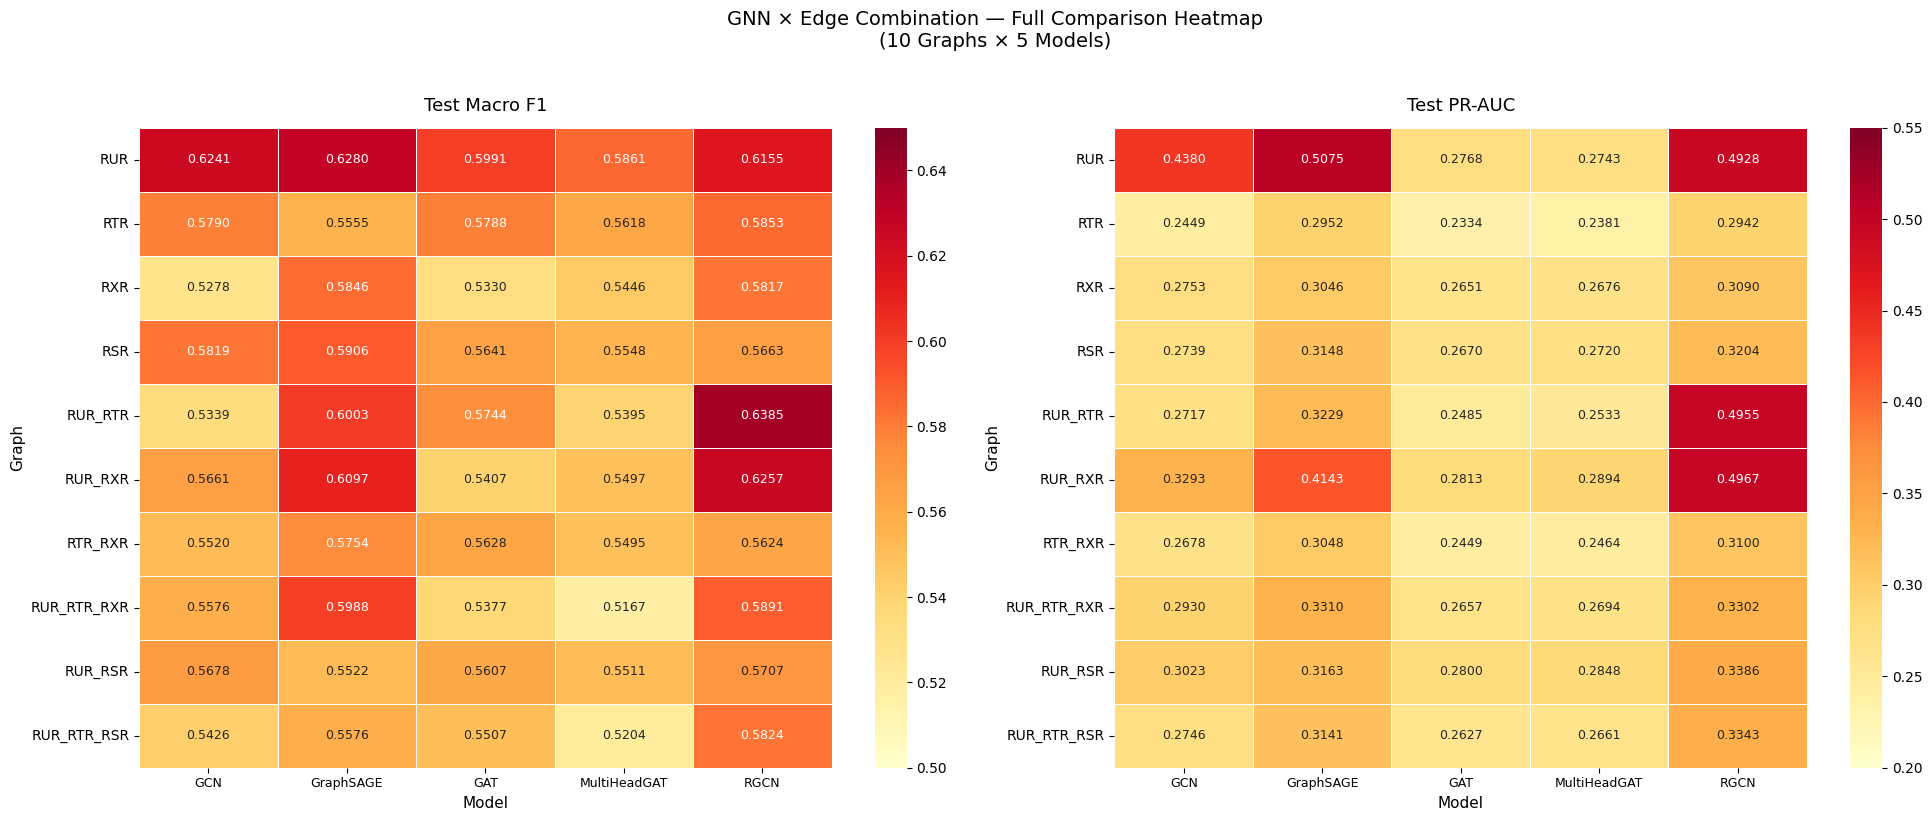

Saved: c:\Users\user\Desktop\project_DScover_연합학술제_GNN\pipeline_1\full_comparison_heatmap.png


In [13]:
# ── Step 5. Heatmap 시각화 ────────────────────────────

col_order = ["GCN", "GraphSAGE", "GAT", "MultiHeadGAT", "RGCN"]
row_order  = GRAPH_NAMES

results_df = pd.DataFrame(all_results)

f1_pivot    = results_df.pivot(index="Graph", columns="Model", values="Test Macro F1")
prauc_pivot = results_df.pivot(index="Graph", columns="Model", values="Test PR-AUC")

f1_pivot    = f1_pivot.reindex(
    index=[r for r in row_order if r in f1_pivot.index],
    columns=[c for c in col_order if c in f1_pivot.columns])
prauc_pivot = prauc_pivot.reindex(
    index=[r for r in row_order if r in prauc_pivot.index],
    columns=[c for c in col_order if c in prauc_pivot.columns])

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

sns.heatmap(f1_pivot, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[0], vmin=0.5, vmax=0.65,
            annot_kws={"size": 9})
axes[0].set_title("Test Macro F1", fontsize=13, pad=12)
axes[0].set_xlabel("Model", fontsize=11)
axes[0].set_ylabel("Graph", fontsize=11)
axes[0].tick_params(axis='x', labelsize=9)

sns.heatmap(prauc_pivot, annot=True, fmt=".4f", cmap="YlOrRd",
            linewidths=0.5, ax=axes[1], vmin=0.2, vmax=0.55,
            annot_kws={"size": 9})
axes[1].set_title("Test PR-AUC", fontsize=13, pad=12)
axes[1].set_xlabel("Model", fontsize=11)
axes[1].set_ylabel("Graph", fontsize=11)
axes[1].tick_params(axis='x', labelsize=9)

fig.suptitle("GNN × Edge Combination — Full Comparison Heatmap\n(10 Graphs × 5 Models)",
             fontsize=14, y=1.02)
plt.tight_layout()

save_path = os.path.join(BASE_DIR, "full_comparison_heatmap.png")
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

In [ ]:
# (?? ?? ?? ?? ? ? ?? ??? ??(Cell 4~6)?? ???)


In [ ]:
# (?? ?? ??? ??? ? ? ???(Cell 6)?? ???)


> 이전 Ablation Study 셀은 전체 그리드 실험(10×5)으로 통합되었습니다.

In [ ]:
# (Ablation Study ? ?? ??? ??(Cell 4)?? ???)
